In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../nba.db")

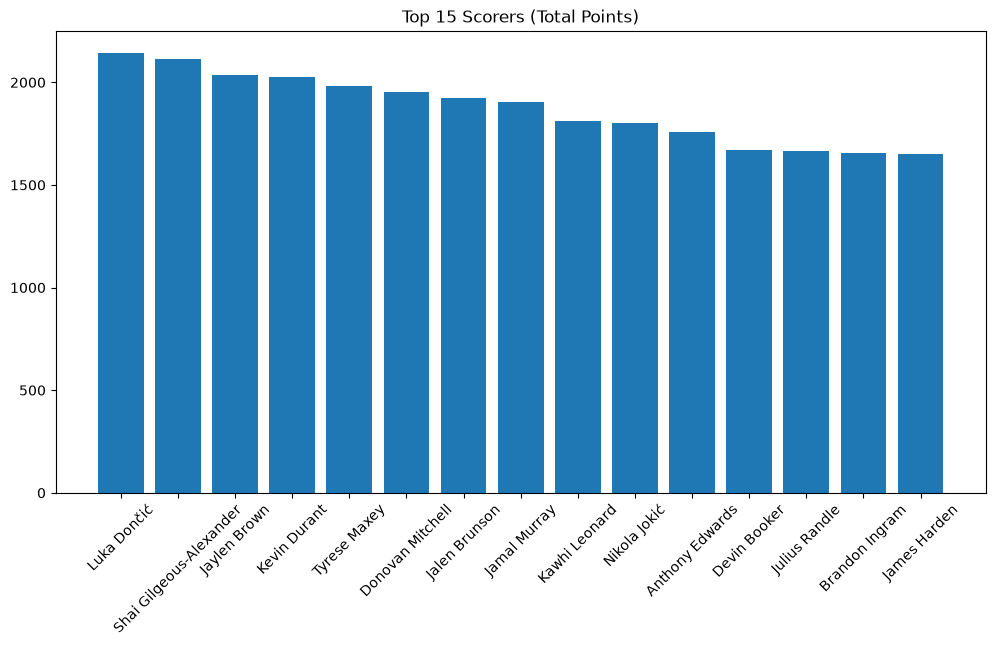

In [13]:
query = """
SELECT PLAYER_NAME, PTS AS PPG, PTS * GP AS TOTAL_POINTS
FROM season_stats
ORDER BY TOTAL_POINTS DESC
LIMIT 15;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))
plt.bar(df['PLAYER_NAME'], df['TOTAL_POINTS'])
plt.xticks(rotation=45)
plt.title("Top 15 Scorers (Total Points)")
plt.show()

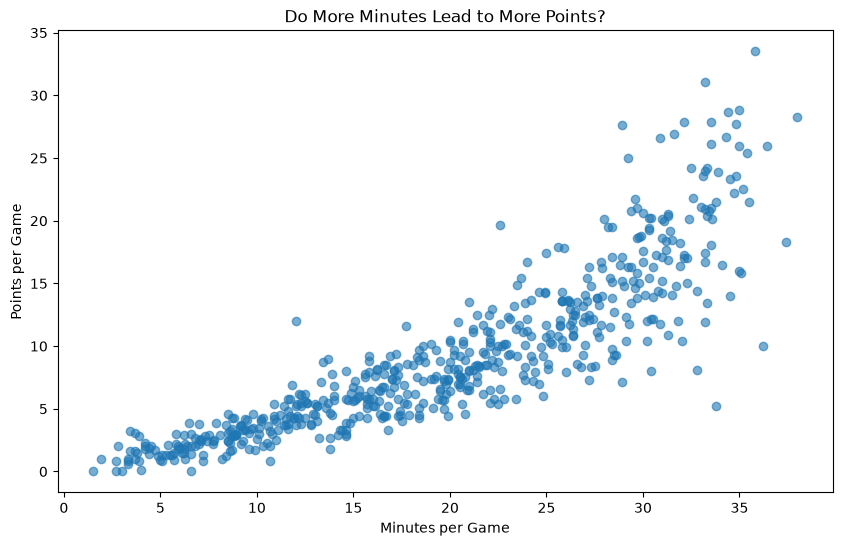

In [14]:
query = """
SELECT PLAYER_NAME, MIN, PTS
FROM season_stats;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,6))
plt.scatter(df['MIN'], df['PTS'], alpha=0.6)
plt.xlabel("Minutes per Game")
plt.ylabel("Points per Game")
plt.title("Do More Minutes Lead to More Points?")
plt.show()

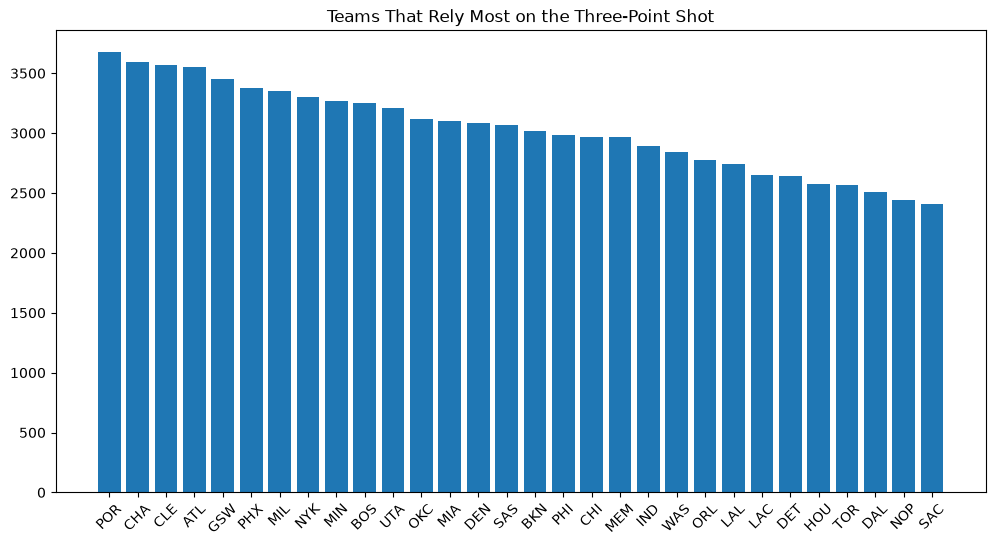

In [15]:
query = """
SELECT TEAM_ABBREVIATION, SUM(FG3A * GP) AS TOTAL_3PA
FROM season_stats
GROUP BY TEAM_ABBREVIATION
ORDER BY TOTAL_3PA DESC;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))
plt.bar(df['TEAM_ABBREVIATION'], df['TOTAL_3PA'])
plt.xticks(rotation=45)
plt.title("Teams That Rely Most on the Three-Point Shot")
plt.show()

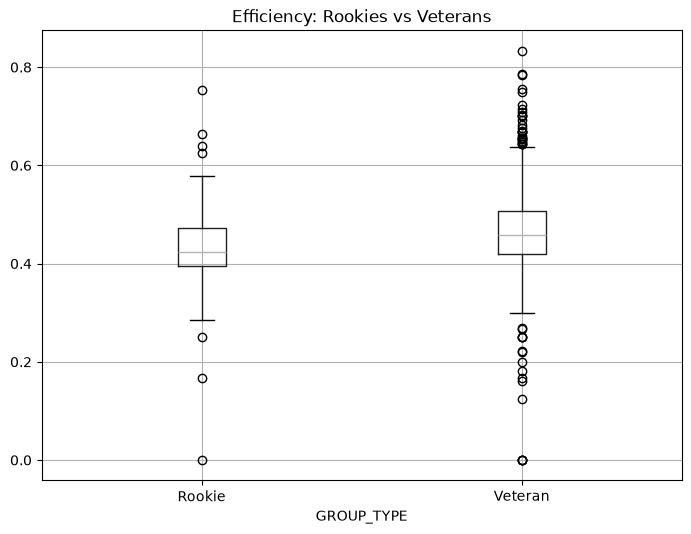

In [16]:
query = """
SELECT
    CASE WHEN r.SEASON = 2025 THEN 'Rookie' ELSE 'Veteran' END AS GROUP_TYPE,
    s.FG_PCT
FROM season_stats s
LEFT JOIN rookies r
ON s.PLAYER_ID = r.PERSON_ID;
"""

df = pd.read_sql_query(query, conn)

df.boxplot(by='GROUP_TYPE', column='FG_PCT', figsize=(8,6))
plt.title("Efficiency: Rookies vs Veterans")
plt.suptitle("")
plt.show()

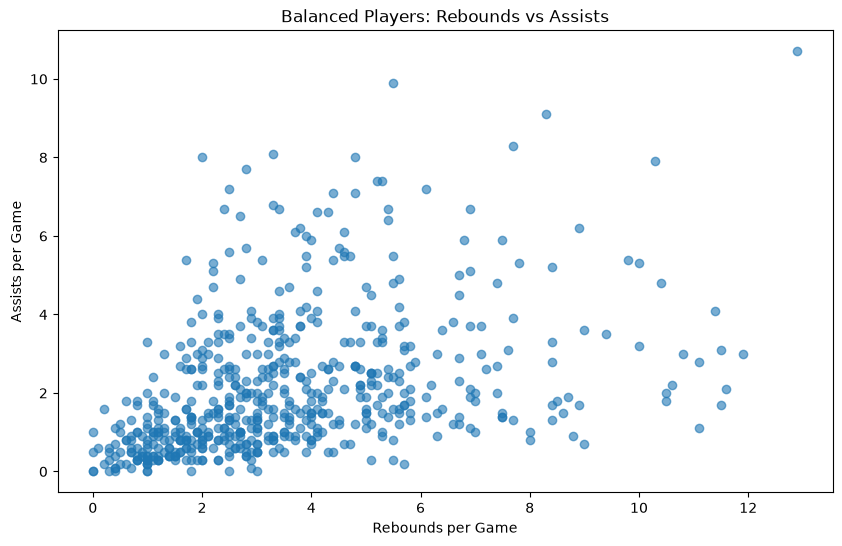

In [17]:
query = """
SELECT PLAYER_NAME, AST, REB
FROM season_stats;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,6))
plt.scatter(df['REB'], df['AST'], alpha=0.6)
plt.xlabel("Rebounds per Game")
plt.ylabel("Assists per Game")
plt.title("Balanced Players: Rebounds vs Assists")
plt.show()